# EDA and Preprocessing for Credit Card Transactions

**Objective:** Explore the `creditcard.csv` dataset, clean and engineer features, handle class imbalance, and produce a processed dataset ready for modeling.

This notebook follows the steps in the project Task 1: Data Cleaning, EDA, Geolocation/feature engineering (templates for `Fraud_Data.csv`), Transformation, and Class Imbalance handling.

In [2]:
# Imports and helper functions
import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import StandardScaler, MinMaxScaler
from sklearn.model_selection import train_test_split
from collections import Counter

# imbalanced-learn (SMOTE)
try:
    from imblearn.over_sampling import SMOTE
except Exception as e:
    print("imblearn not available. Install with: pip install imbalanced-learn")

pd.set_option('display.max_columns', 120)
pd.set_option('display.width', 200)

DATA_DIR = os.path.join('..','data','raw')
PROCESSED_DIR = os.path.join('..','data','processed')
os.makedirs(PROCESSED_DIR, exist_ok=True)

# Helpers

def show_missing_and_duplicates(df: pd.DataFrame):
    missing = df.isna().sum()
    dups = df.duplicated().sum()
    print(f"Shape: {df.shape}")
    print("Missing values (top 10):")
    print(missing[missing>0].sort_values(ascending=False).head(10))
    print(f"Duplicates: {dups}")


In [2]:
# Quick preview (read a small sample first)
sample_path = os.path.join('..','data','raw','creditcard.csv')
print('Sample path:', sample_path)
df_sample = pd.read_csv(sample_path, nrows=1000)
df_sample.head()


Sample path: ..\data\raw\creditcard.csv


,Time,V1,V2,V3,V4,V5,V6,V7,V8,V9,V10,V11,V12,V13,V14,V15,V16,V17,V18,V19,V20,V21,V22,V23,V24,V25,V26,V27,V28,Amount,Class
0,0,-1.359807,-0.072781,2.536347,1.378155,-0.338321,0.462388,0.239599,0.098698,0.363787,0.090794,-0.551600,-0.617801,-0.991390,-0.311169,1.468177,-0.470401,0.207971,0.025791,0.403993,0.251412,-0.018307,0.277838,-0.110474,0.066928,0.128539,-0.189115,0.133558,-0.021053,149.62,0
1,0,1.191857,0.266151,0.166480,0.448154,0.060018,-0.082361,-0.078803,0.085102,-0.255425,-0.166974,1.612727,1.065235,0.489095,-0.143772,0.635558,0.463917,-0.114805,-0.183361,-0.145783,-0.069083,-0.225775,-0.638672,0.101288,-0.339846,0.167170,0.125895,-0.008983,0.014724,2.69,0
2,1,-1.358354,-1.340163,1.773209,0.379780,-0.503198,1.800499,0.791461,0.247676,-1.514654,0.207643,0.624501,0.066084,0.717293,-0.165946,2.345865,-2.890083,1.109969,-0.121359,-2.261857,0.524980,0.247998,0.771679,0.909412,-0.689281,-0.327642,-0.139097,-0.055353,-0.059752,378.66,0
3,1,-0.966272,-0.185226,1.792993,-0.863291,-0.010309,1.247203,0.237609,0.377436,-1.387024,-0.054952,-0.226487,0.178228,0.507757,-0.287924,-0.631418,-1.059647,-0.684093,1.965775,-1.232622,-0.208038,-0.108300,0.005274,-0.190321,-1.175575,0.647376,-0.221929,0.062723,0.061458,123.50,0
4,2,-1.158233,0.877737,1.548718,0.403034,-0.407193,0.095921,0.592941,-0.270533,0.817739,0.753074,-0.822843,0.538196,1.345852,-1.119670,0.175121,-0.451449,-0.237033,-0.038195,0.803487,0.408542,-0.009431,0.798278,-0.137458,0.141267,-0.206010,0.502292,0.219422,0.215153,69.99,0


In [3]:
# Load the full dataset (careful with memory)
# creditcard.csv is large - set low_memory=False, dtype inference by pandas
full_path = os.path.join('..','data','raw','creditcard.csv')
df = pd.read_csv(full_path, low_memory=False)

# Basic info
show_missing_and_duplicates(df)

df.info()

df.describe().T


Shape: (284807, 31)
Missing values (top 10):
Series([], dtype: int64)
Duplicates: 1081
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 284807 entries, 0 to 284806
Data columns (total 31 columns):
 #   Column  Non-Null Count   Dtype  
---  ------  --------------   -----  
 0   Time    284807 non-null  float64
 1   V1      284807 non-null  float64
 2   V2      284807 non-null  float64
 3   V3      284807 non-null  float64
 4   V4      284807 non-null  float64
 5   V5      284807 non-null  float64
 6   V6      284807 non-null  float64
 7   V7      284807 non-null  float64
 8   V8      284807 non-null  float64
 9   V9      284807 non-null  float64
 10  V10     284807 non-null  float64
 11  V11     284807 non-null  float64
 12  V12     284807 non-null  float64
 13  V13     284807 non-null  float64
 14  V14     284807 non-null  float64
 15  V15     284807 non-null  float64
 16  V16     284807 non-null  float64
 17  V17     284807 non-null  float64
 18  V18     284807 non-null  float64
 19 

,count,mean,std,min,25%,50%,75%,max
Time,284807.0,9.481386e+04,47488.145955,0.000000,54201.500000,84692.000000,139320.500000,172792.000000
V1,284807.0,1.168375e-15,1.958696,-56.407510,-0.920373,0.018109,1.315642,2.454930
V2,284807.0,3.416908e-16,1.651309,-72.715728,-0.598550,0.065486,0.803724,22.057729
V3,284807.0,-1.379537e-15,1.516255,-48.325589,-0.890365,0.179846,1.027196,9.382558
V4,284807.0,2.074095e-15,1.415869,-5.683171,-0.848640,-0.019847,0.743341,16.875344
V5,284807.0,9.604066e-16,1.380247,-113.743307,-0.691597,-0.054336,0.611926,34.801666
V6,284807.0,1.487313e-15,1.332271,-26.160506,-0.768296,-0.274187,0.398565,73.301626
V7,284807.0,-5.556467e-16,1.237094,-43.557242,-0.554076,0.040103,0.570436,120.589494
V8,284807.0,1.213481e-16,1.194353,-73.216718,-0.208630,0.022358,0.327346,20.007208
V9,284807.0,-2.406331e-15,1.098632,-13.434066,-0.643098,-0.051429,0.597139,15.594995


In [4]:
# Data Cleaning
# 1) Remove duplicates
initial_shape = df.shape

df = df.drop_duplicates()
print(f"Dropped {initial_shape[0]-df.shape[0]} duplicate rows")

# 2) Missing values
print('Missing totals:')
print(df.isna().sum()[df.isna().sum()>0])

# 3) Correct dtypes if necessary (most columns are numeric in the dataset)
# For this dataset, typical columns: Time, V1..V28, Amount, Class

# Confirm expected columns exist
print('Columns:', df.columns.tolist()[:20])


Dropped 1081 duplicate rows
Missing totals:
Series([], dtype: int64)
Columns: ['Time', 'V1', 'V2', 'V3', 'V4', 'V5', 'V6', 'V7', 'V8', 'V9', 'V10', 'V11', 'V12', 'V13', 'V14', 'V15', 'V16', 'V17', 'V18', 'V19']


Class counts:
 Class
0    283253
1       473
Name: count, dtype: int64

Class proportions:
 Class
0    0.998333
1    0.001667
Name: count, dtype: float64


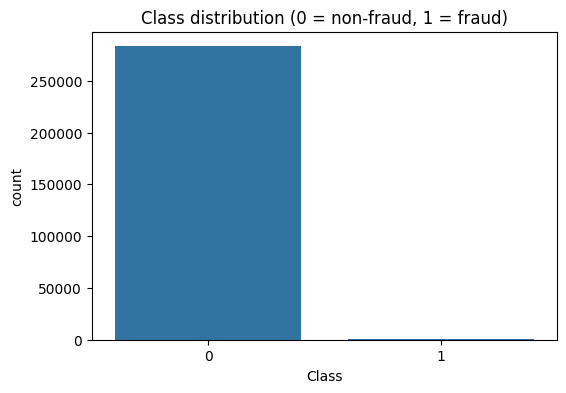

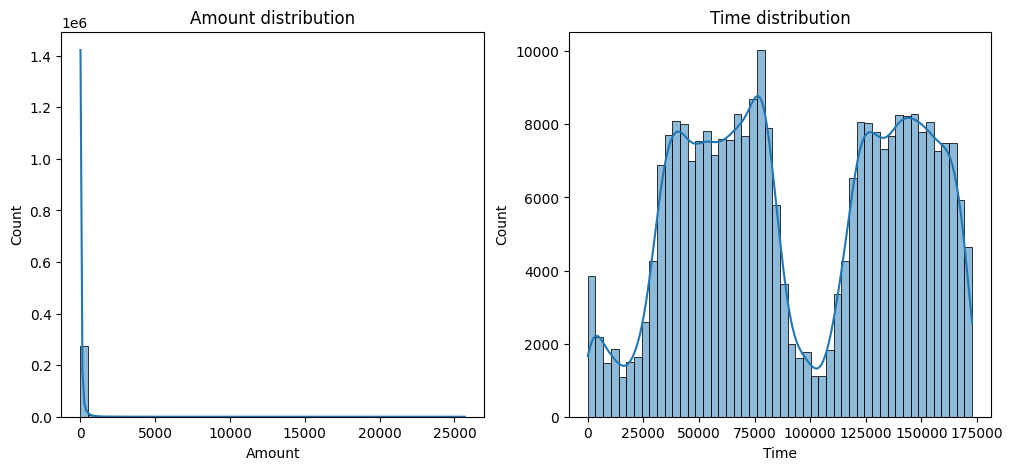

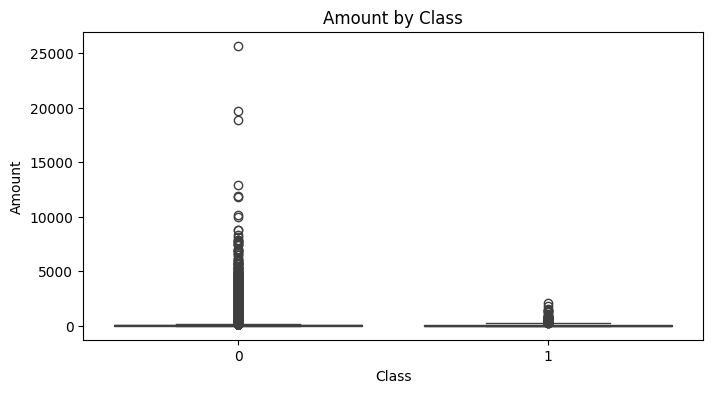

In [5]:
# Exploratory Data Analysis (EDA)

# 1) Class distribution
class_counts = df['Class'].value_counts()
print('Class counts:\n', class_counts)
print('\nClass proportions:\n', class_counts / class_counts.sum())

plt.figure(figsize=(6,4))
sns.countplot(x='Class', data=df)
plt.title('Class distribution (0 = non-fraud, 1 = fraud)')
plt.show()

# 2) Univariate: Amount and Time distributions
plt.figure(figsize=(12,5))
plt.subplot(1,2,1)
sns.histplot(df['Amount'], bins=50, kde=True)
plt.title('Amount distribution')

plt.subplot(1,2,2)
sns.histplot(df['Time'], bins=50, kde=True)
plt.title('Time distribution')
plt.show()

# Boxplots by class for Amount
plt.figure(figsize=(8,4))
sns.boxplot(x='Class', y='Amount', data=df)
plt.title('Amount by Class')
plt.show()


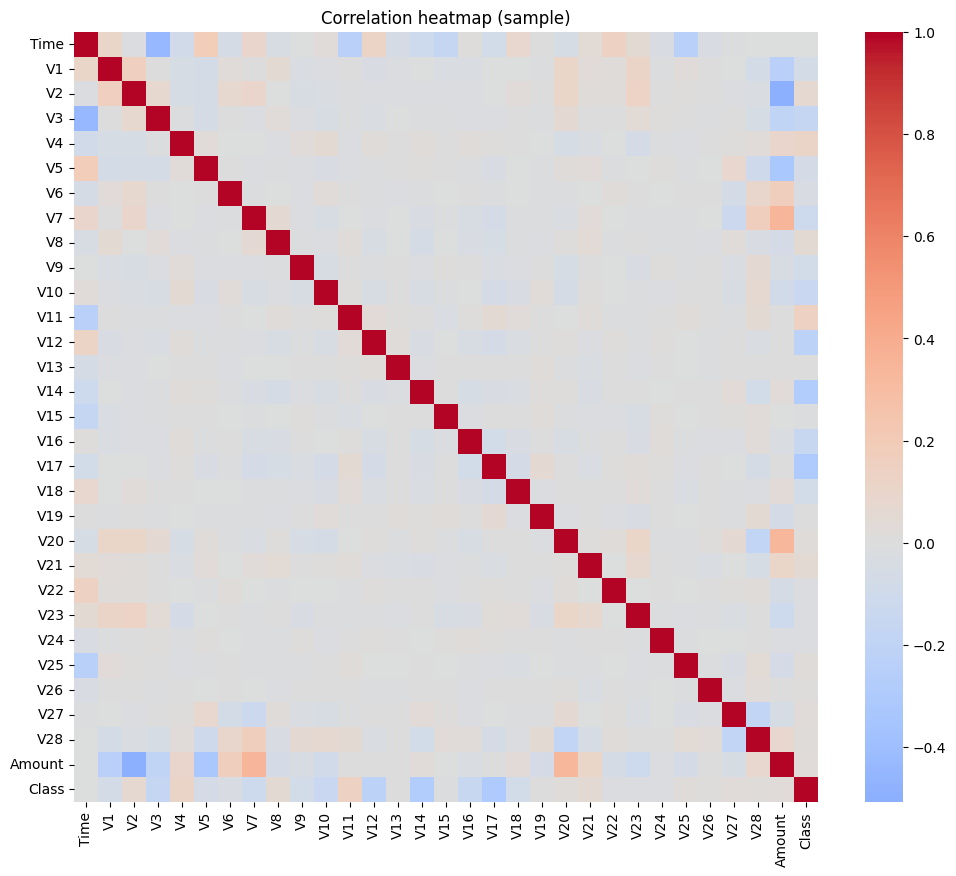

        count        mean  median         std
Class                                        
0      283253   88.413575   22.00  250.379023
1         473  123.871860    9.82  260.211041


In [6]:
# Bivariate analysis: correlations and fraud relationships
# Correlation heatmap (on a sample to manage compute)
sample_corr = df.sample(n=min(10000, len(df)), random_state=42).corr()
plt.figure(figsize=(12,10))
sns.heatmap(sample_corr, cmap='coolwarm', center=0)
plt.title('Correlation heatmap (sample)')
plt.show()

# Compare mean Amount for classes
print(df.groupby('Class')['Amount'].agg(['count','mean','median','std']))


In [7]:
# Feature engineering for creditcard dataset
# Create log amount and hour of day derived from Time

df['Amount_log'] = np.log1p(df['Amount'])
# The "Time" column is seconds since the first transaction in dataset; use modulo day to create hour_of_day
seconds_in_day = 24*3600
df['hour_of_day'] = (df['Time'] % seconds_in_day)//3600

# Scale Amount and Time (demonstration)
scaler = StandardScaler()
df[['Amount_scaled','Time_scaled']] = scaler.fit_transform(df[['Amount','Time']])

# Quick check
print(df[['Amount','Amount_log','Amount_scaled','Time','hour_of_day','Time_scaled']].head())


   Amount  Amount_log  Amount_scaled  Time  hour_of_day  Time_scaled
0  149.62    5.014760       0.244200   0.0          0.0    -1.996823
1    2.69    1.305626      -0.342584   0.0          0.0    -1.996823
2  378.66    5.939276       1.158900   1.0          0.0    -1.996802
3  123.50    4.824306       0.139886   1.0          0.0    -1.996802
4   69.99    4.262539      -0.073813   2.0          0.0    -1.996781


In [ ]:
# Handling class imbalance — split and apply SMOTE to training set only
X = df.drop(columns=['Class'])
y = df['Class']

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.25, random_state=42, stratify=y)

print('Before resampling:', Counter(y_train))

# Use SMOTE on training set — justification: preserves all majority class samples while creating synthetic minority examples, useful when minority is very small
sm = SMOTE(random_state=42)
X_res, y_res = sm.fit_resample(X_train.select_dtypes(include=[np.number]), y_train)
print('After resampling:', Counter(y_res))

# Save before/after plots for documentation
import matplotlib.pyplot as plt
plt.figure()
pd.Series(y_train).value_counts().sort_index().plot(kind='bar')
plt.title('Train class distribution BEFORE SMOTE')
plt.savefig('../reports/figures/cc_class_distribution_before.png')
plt.close()

plt.figure()
pd.Series(y_res).value_counts().sort_index().plot(kind='bar')
plt.title('Train class distribution AFTER SMOTE')
plt.savefig('../reports/figures/cc_class_distribution_after.png')
plt.close()

# If using non-numeric columns (not the case here), encode before SMOTE using pipelines or ColumnTransformer


Before resampling: Counter({0: 213236, 1: 369})
After resampling: Counter({0: 213236, 1: 213236})


: 

In [9]:
# Save processed dataset
proc_path = os.path.join('..','data','processed','creditcard_processed.csv')
# Save a compact set of features including engineered fields
cols_to_save = ['Time','hour_of_day','Amount','Amount_log','Amount_scaled','Time_scaled'] + [c for c in df.columns if c.startswith('V')]
df[cols_to_save + ['Class']].to_csv(proc_path, index=False)
print('Saved processed file to', proc_path)


Saved processed file to ..\data\processed\creditcard_processed.csv


---
# Templates: Geolocation merging & Feature Engineering for Fraud_Data.csv 🔧

This section contains reusable functions and example steps to: convert IPv4 addresses to integers, perform a range-based lookup against `IpAddress_to_Country.csv`, and engineer time/velocity features for `Fraud_Data.csv`.


In [10]:
# IP conversion and interval join utilities
import ipaddress


def ipv4_to_int(ip_str: str) -> int:
    try:
        return int(ipaddress.IPv4Address(ip_str))
    except Exception:
        return np.nan

# Example: Prepare ip mapping and do merge
ip_map_path = os.path.join('..','data','raw','IpAddress_to_Country.csv')
print('IP map path:', ip_map_path)

# Load ip map (requires columns with start and end ip as integers or strings)
try:
    ip_map = pd.read_csv(ip_map_path)
    # If the mapping has start and end strings, convert
    if 'start_ip' in ip_map.columns and ip_map['start_ip'].dtype == object:
        ip_map['start_int'] = ip_map['start_ip'].apply(ipv4_to_int)
    if 'end_ip' in ip_map.columns and ip_map['end_ip'].dtype == object:
        ip_map['end_int'] = ip_map['end_ip'].apply(ipv4_to_int)
    # Make sure sorted for asof-like joins
    ip_map = ip_map.sort_values('start_int').dropna(subset=['start_int','end_int'])
    ip_map.head()
except FileNotFoundError:
    print('IpAddress_to_Country.csv not found in expected path; please add it to run mapping.')


IP map path: ..\data\raw\IpAddress_to_Country.csv


KeyError: 'start_int'

In [ ]:
# Example of merging: given Fraud_Data.csv with an IP column named 'ip_address' (string)
fraud_path = os.path.join('..','data','raw','Fraud_Data.csv')

try:
    fdf = pd.read_csv(fraud_path, low_memory=False)
    print('Fraud_Data sample columns:', fdf.columns.tolist()[:20])
    # Convert ip strings to ints
    if 'ip_address' in fdf.columns:
        fdf['ip_int'] = fdf['ip_address'].apply(ipv4_to_int)
        # For each ip, find the mapping row where start_int <= ip_int <= end_int
        # Efficient approach: sort and use interval search (example uses a merge by closest start, then filter with end)
        fdf = fdf.sort_values('ip_int')
        ip_map_for_merge = ip_map[['start_int','end_int','country']].sort_values('start_int')
        merged = pd.merge_asof(fdf, ip_map_for_merge, left_on='ip_int', right_on='start_int', direction='backward')
        # Keep only rows where ip_int <= end_int
        merged['country'] = merged.apply(lambda r: r['country'] if r['ip_int']<=r['end_int'] else np.nan, axis=1)
        print('Merged sample (ip -> country):')
        display(merged[['ip_address','ip_int','country']].head())
    else:
        print('`ip_address` column not found in Fraud_Data.csv — adapt column name accordingly.')
except FileNotFoundError:
    print('Fraud_Data.csv not found in data/raw — place it there to run the example.')


In [ ]:
# Feature engineering suggestions for Fraud_Data.csv (velocity & time-based features)
# - transactions_per_user_{window}
# - time_since_signup
# - hour_of_day, day_of_week
# Example (requires columns: user_id, purchase_time, signup_time)

try:
    if 'fdf' in globals():
        # Ensure times are datetime
        for col in ['purchase_time','signup_time']:
            if col in fdf.columns:
                fdf[col] = pd.to_datetime(fdf[col])
        
        # Transactions per user in last 24h, 7d example
        if 'user_id' in fdf.columns and 'purchase_time' in fdf.columns:
            fdf = fdf.sort_values(['user_id','purchase_time'])
            fdf['tx_last_24h'] = fdf.groupby('user_id')['purchase_time'].apply(lambda s: s.rolling('24h', on='purchase_time').count())
        
        # time_since_signup
        if 'signup_time' in fdf.columns and 'purchase_time' in fdf.columns:
            fdf['time_since_signup'] = (fdf['purchase_time'] - fdf['signup_time']).dt.total_seconds()/3600.0
        
        fdf.head()
    else:
        print('Fraud_Data sample not loaded; see earlier cell to load and merge IPs.')
except Exception as e:
    print('Example feature-engineering step failed:', str(e))


## Summary, next steps and notes ✅

- Data cleaning: duplicates removed; credit card dataset contains no missing values (confirmed in earlier cells).
- EDA: Class is extremely imbalanced (fraud is rare); Amount and Time show different distributions.
- Feature engineering: added log(amount), hour_of_day, scaled Amount/Time.
- Class imbalance: applied SMOTE to the **training set only** and saved before/after visuals at `reports/figures/cc_class_distribution_before.png` and `reports/figures/cc_class_distribution_after.png`. Justification: oversampling the minority with synthetic examples helps models learn minority patterns without discarding majority data; always apply resampling only to training splits to avoid leakage.

Next steps:
1) Run modeling experiments with the processed dataset and perform cross-validation using stratified folds. ✅
2) For `Fraud_Data.csv`: run the IP→country merge using the IP mapping and then compute country-level fraud rates and additional velocity features. ✅
3) Consider trying undersampling + ensemble methods (BalancedRandomForest) or class-weighted losses as alternatives to SMOTE.

---

Notes: If you want, I can also add a `preprocessing.py` function that performs all of the above steps programmatically and is reused across training scripts.